### Objective
0. Run after neur4.ipynb
1. Stimulus.  
a. Does population encode a stimulus axis? PCA & Regression. No.  
b. Does pairwise neural similarity depend systematically on condition? RDMs. Kinda.  
c. Same, but for on-manifold similarity. TBD.  
d. Is neural similarity based on absolute or relative positional proximity?  
e. Is context-dependent stimulus class decodable? Decoding accuracy. No, but absolute class is..  

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection
from sklearn.decomposition import PCA


plot settings

In [15]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# %matplotlib widget
%matplotlib inline

variables & helpers (from neur4)

In [16]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs.csv')
# trials col first
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]
patients = psychopy_df['subj'].unique().tolist()
for patient in [1.1, 1.11, 1.111, 1.1111, 9, 11]: patients.remove(patient)
conditions = ['curv_comp', 'baseline', 'flat_comp']

print(f'neural patients: {patients}')
print(f'conditions: {conditions}')

neural patients: [12.0, 18.0, 21.0, 22.0]
conditions: ['curv_comp', 'baseline', 'flat_comp']


In [17]:
def get_pt_metadata(psychopy_df, patient, verbose=True):
    pt_data_dir = f'../../results/2025{int(patient)}/records/processed_data'
    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs   = len(pt_neur_df)
    if verbose: print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    pt_data_dir = f'../../results/2025{int(patient)}/records/processed_data'
    pt_epoch_spikes     = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                    for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs  = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)
    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins


def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    cont_trials, cont_labels = [], []
    if contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'shape_class':
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    if verbose: print(f'contrast: {contrast}')
    return cont_trials, cont_labels


### a. Does population encode a stimulus axis? PCA & Regression.

In [18]:
epoch = 'stim'

# per patient, compute trial by neuron FR, by avging across bins
pt_data = {}
for patient in patients:
    pt_psychopy_df, _, pt_num_neurs = get_pt_metadata(psychopy_df, patient, verbose=False)
    _, _, pt_epoch_FRs, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)
    meanFRs = pt_epoch_FRs.mean(axis=2)        # (240, n_neurs)
    pt_data[patient] = {'psychopy': pt_psychopy_df, 'meanFRs': meanFRs, 'n_neurs': pt_num_neurs}

# per patient and condition,compute stim by neuron FR
cond_pt_means = {}
for cond in conditions:
    cond_pt_means[cond] = {}
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        cond_mask      = (pt_psychopy_df['condition'] == cond).values
        cond_stims     = pt_psychopy_df.loc[cond_mask, 'true_stim'].round(2).values
        cond_meanFRs   = pt_data[patient]['meanFRs'][cond_mask]
        df_tmp = pd.DataFrame(cond_meanFRs)
        df_tmp['true_stim'] = cond_stims
        cond_pt_means[cond][patient] = df_tmp.groupby('true_stim').mean()  # (n_unique_pos, n_neurs)

# stack neurons across patients → PCA sees one shared population geometry
cond_matrices, cond_pos_values = {}, {}
for cond in conditions:
    all_stims = sorted(cond_pt_means[cond][patients[0]].index)
    FR_stimXneur = np.hstack([cond_pt_means[cond][pt].loc[all_stims].values for pt in patients])
    cond_matrices[cond]   = FR_stimXneur
    cond_pos_values[cond] = np.array(all_stims)
    print(f'{cond}: {len(all_stims)} unique true_stim values, matrix {FR_stimXneur.shape}')

total_neurs = FR_stimXneur.shape[1]
print(f'\ntotal neurons across patients: {total_neurs}')

curv_comp: 15 unique true_stim values, matrix (15, 57)
baseline: 20 unique true_stim values, matrix (20, 57)
flat_comp: 15 unique true_stim values, matrix (15, 57)

total neurons across patients: 57


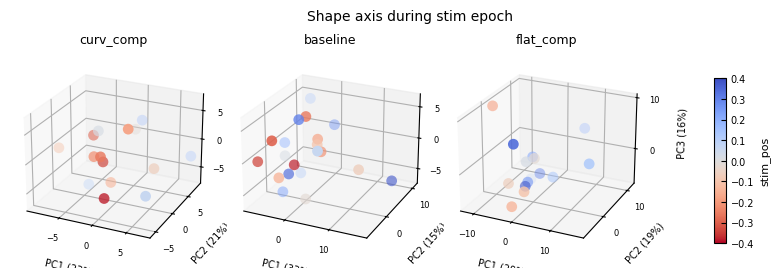

In [19]:
# does each boundary context have its own shape axis?
# fit PCA separately so each condition gets its own coordinate frame
view_elev, view_azim = 24, -65

fig = plt.figure(figsize=(8, 3))
for i, cond in enumerate(conditions, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    pca    = PCA(n_components=3)
    coords = pca.fit_transform(cond_matrices[cond])
    ev     = pca.explained_variance_ratio_
    sc     = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                        c=cond_pos_values[cond], cmap='coolwarm_r', vmin=-0.4, vmax=0.4,
                        s=60, linewidths=0)
    ax.set_title(cond, fontsize=9)
    ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_zlabel(f'PC3 ({ev[2]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.tick_params(labelsize=6, pad=0)
    ax.locator_params(nbins=3)
    ax.view_init(elev=view_elev, azim=view_azim)

cbar_ax = fig.add_axes([0.88, 0.2, 0.015, 0.55])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('stim_pos', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle(f'Shape axis during {epoch} epoch', fontsize=10)
plt.subplots_adjust(left=0.0, right=0.8, wspace=0.05)
plt.show()

condition     R² (LOO-CV)
curv_comp           0.064
baseline           -0.432
flat_comp          -0.811


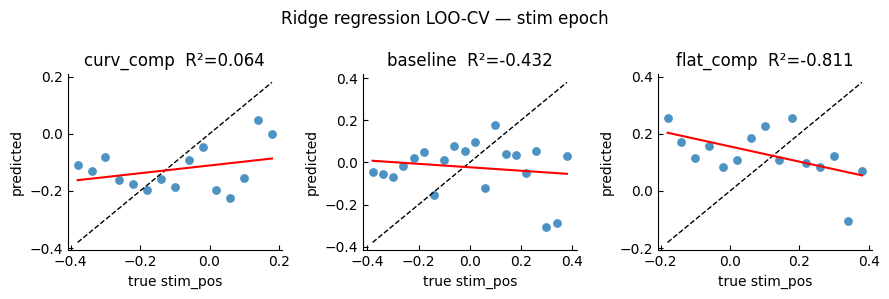

In [20]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

# does the population (original space) linearly encode stim_pos per condition?
# ridge regularization needed: 57 features >> 15-20 stim_pos samples
loo = LeaveOneOut()

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
print(f"{'condition':<12} {'R² (LOO-CV)':>12}")
for ax, cond in zip(axs, conditions):
    X, y = cond_matrices[cond], cond_pos_values[cond]
    y_pred = np.empty_like(y)
    for train, test in loo.split(X):
        y_pred[test] = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(X[train], y[train]).predict(X[test])
    r2 = r2_score(y, y_pred)
    print(f"{cond:<12} {r2:>12.3f}")

    ax.scatter(y, y_pred, s=40, alpha=0.8, linewidths=0)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='identity')
    m, b = np.polyfit(y, y_pred, 1)
    x_line = np.linspace(y.min(), y.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5, label='best fit')
    ax.set(xlabel='true stim_pos', ylabel='predicted', title=f'{cond}  R²={r2:.3f}')

plt.suptitle(f'Ridge regression LOO-CV — {epoch} epoch')
plt.tight_layout()
plt.show()

### b. Does pairwise neural similarity track positional similarity? RSA and spearman.

In [21]:
# # what stim positions were sampled per condition, and where does the boundary fall?
# # explains the asymmetric coverage in curv/flat that causes black rows/cols in the DSM

# fig, axs = plt.subplots(1, 3, figsize=(9, 3))
# for ax, cond in zip(axs, conditions):
#     sub = psychopy_df[psychopy_df['condition'] == cond]
#     stims    = sub['true_stim'].round(2)
#     pos_vals = sorted(stims.unique())
#     counts   = stims.value_counts().sort_index()

#     ax.bar(pos_vals, counts.values, width=0.03, color='steelblue', alpha=0.7)
#     for div in sorted(sub['true_boundary'].unique()):
#         ax.axvline(div, color='r', linewidth=1.5, linestyle='--', label=f'boundary={div:.2f}')
#     ax.set_xlim(-0.45, 0.45)
#     ax.set_xlabel('true_stim')
#     ax.set_ylabel('# trials')
#     ax.set_title(cond)
#     ax.set_xticks(pos_vals)
#     ax.set_xticklabels([f'{v:.2f}' for v in pos_vals], rotation=90, fontsize=5)
#     ax.legend(fontsize=7, frameon=False)

# plt.suptitle('Stimulus sampling per condition')
# plt.tight_layout()
# plt.show()

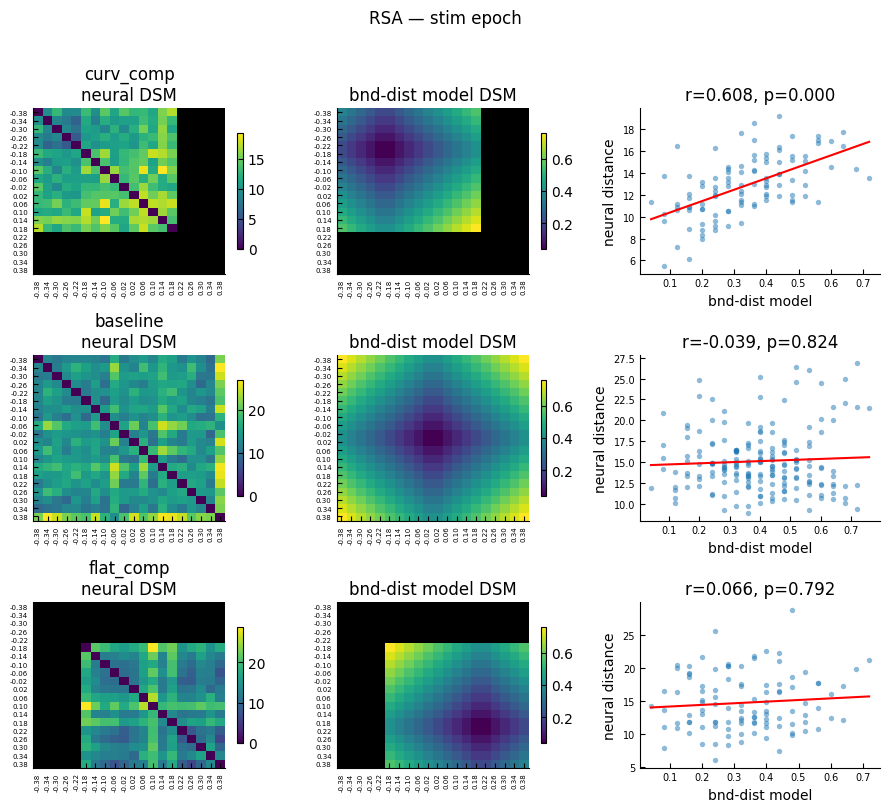

In [22]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# rows/cols = union of all sampled stim positions across conditions
# cells where a condition didn't sample that position are blacked out
n_perms = 1000
rng = np.random.default_rng(0)

# boundary position per condition (needed for stimulus model)
cond_boundary = {
    cond: psychopy_df[psychopy_df['condition'] == cond]['true_boundary'].mean()
    for cond in conditions
}

all_stims_union = sorted(set().union(*[set(cond_pos_values[c]) for c in conditions]))
n_union = len(all_stims_union)
stim_to_idx = {s: i for i, s in enumerate(all_stims_union)}

cmap_dsm = plt.cm.viridis.copy()
cmap_dsm.set_bad('black')

tick_labels = [f'{s:.2f}' for s in all_stims_union]

fig, axs = plt.subplots(3, 3, figsize=(9, 8))

for row, cond in enumerate(conditions):
    X, y = cond_matrices[cond], cond_pos_values[cond]
    sampled_idx = [stim_to_idx[s] for s in y]

    # stimulus model: dissim(i,j) = stim_dist_to_bnd[i] + stim_dist_to_bnd[j]
    # both near boundary → low; both far → high
    stim_dist_to_bnd = np.abs(y - cond_boundary[cond])
    bnd_model_dissim = stim_dist_to_bnd[:, None] + stim_dist_to_bnd[None, :]

    # full DSMs with NaN for unsampled positions → displayed as black
    D_neural_sq = squareform(pdist(X))
    D_neural_full = np.full((n_union, n_union), np.nan)
    D_stim_full   = np.full((n_union, n_union), np.nan)
    for i, si in enumerate(sampled_idx):
        for j, sj in enumerate(sampled_idx):
            D_neural_full[si, sj] = D_neural_sq[i, j]
            D_stim_full[si, sj]   = bnd_model_dissim[i, j]

    # Mantel test on sampled pairs only
    triu_idx = np.triu_indices(len(y), k=1)
    D_neural_vec = pdist(X)
    D_stim_vec   = bnd_model_dissim[triu_idx]
    r_obs, _ = spearmanr(D_neural_vec, D_stim_vec)
    r_perm = np.empty(n_perms)
    for k in range(n_perms):
        d_perm = np.abs(rng.permutation(y) - cond_boundary[cond])
        r_perm[k] = spearmanr(D_neural_vec, (d_perm[:, None] + d_perm[None, :])[triu_idx])[0]
    p = (np.abs(r_perm) >= np.abs(r_obs)).mean()

    # neural DSM
    ax = axs[row, 0]
    im = ax.imshow(D_neural_full, cmap=cmap_dsm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title=f'{cond}\nneural DSM')
    ax.set_xticks(range(n_union)); ax.set_xticklabels(tick_labels, rotation=90, fontsize=5)
    ax.set_yticks(range(n_union)); ax.set_yticklabels(tick_labels, fontsize=5)

    # stimulus model DSM (same mask)
    ax = axs[row, 1]
    im = ax.imshow(D_stim_full, cmap=cmap_dsm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title='bnd-dist model DSM')
    ax.set_xticks(range(n_union)); ax.set_xticklabels(tick_labels, rotation=90, fontsize=5)
    ax.set_yticks(range(n_union)); ax.set_yticklabels(tick_labels, fontsize=5)

    # scatter with line of best fit
    ax = axs[row, 2]
    ax.scatter(D_stim_vec, D_neural_vec, s=15, alpha=0.5, linewidths=0)
    m, b = np.polyfit(D_stim_vec, D_neural_vec, 1)
    x_line = np.linspace(D_stim_vec.min(), D_stim_vec.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5)
    ax.set(xlabel='bnd-dist model', ylabel='neural distance', title=f'r={r_obs:.3f}, p={p:.3f}')
    ax.tick_params(labelsize=7)

plt.suptitle(f'RSA — {epoch} epoch', y=1.01)
plt.tight_layout()
plt.show()

### c. Same, but for on-manifold similarity.

### d. Is neural similarity based on absolute or relative positional proximity?  

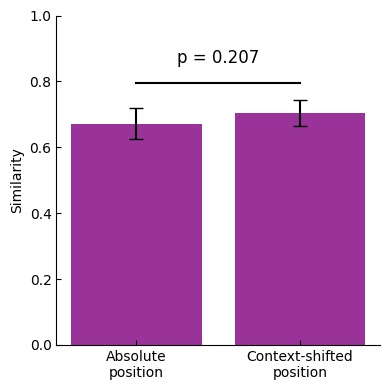

In [33]:
from scipy.stats import ttest_rel

# --- Context-shift alignment MSEs: absolute vs boundary-relative neural patterns ---
neural_align_rows = []

for patient in patients:
    for cond_a, cond_b in cond_pairs:
        boundary_a = cond_boundary[cond_a]
        boundary_b = cond_boundary[cond_b]

        a_abs_pos = cond_pt_means[cond_a][patient].index.to_numpy().round(3)
        b_abs_pos = cond_pt_means[cond_b][patient].index.to_numpy().round(3)
        a_rel_pos = (a_abs_pos - boundary_a).round(3)
        b_rel_pos = (b_abs_pos - boundary_b).round(3)

        a_abs_df = pd.DataFrame(cond_pt_means[cond_a][patient].values, index=a_abs_pos)
        b_abs_df = pd.DataFrame(cond_pt_means[cond_b][patient].values, index=b_abs_pos)
        a_rel_df = pd.DataFrame(cond_pt_means[cond_a][patient].values, index=a_rel_pos)
        b_rel_df = pd.DataFrame(cond_pt_means[cond_b][patient].values, index=b_rel_pos)

        # absolute: compare neural patterns at same true_stim
        shared_abs = np.intersect1d(a_abs_df.index.values, b_abs_df.index.values)
        abs_mse = np.nan
        if len(shared_abs) > 0:
            abs_diff = a_abs_df.loc[shared_abs].values - b_abs_df.loc[shared_abs].values
            abs_mse = np.mean(abs_diff ** 2)

        # boundary-relative: compare neural patterns at same stim_boundary_aligned
        shared_rel = np.intersect1d(a_rel_df.index.values, b_rel_df.index.values)
        rel_mse = np.nan
        if len(shared_rel) > 0:
            rel_diff = a_rel_df.loc[shared_rel].values - b_rel_df.loc[shared_rel].values
            rel_mse = np.mean(rel_diff ** 2)

        neural_align_rows.append({
            'patient': patient,
            'cond_pair': f'{cond_a} vs {cond_b}',
            'abs_mse': abs_mse,
            'rel_mse': rel_mse,
            'n_abs_overlap': len(shared_abs),
            'n_rel_overlap': len(shared_rel),
        })

neural_align_df = pd.DataFrame(neural_align_rows).dropna(subset=['abs_mse', 'rel_mse'])
all_abs_MSEs = neural_align_df['abs_mse'].values
all_rel_MSEs = neural_align_df['rel_mse'].values

t_stat, p_val = ttest_rel(all_abs_MSEs, all_rel_MSEs)

fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

alpha = .1  # adjust as needed for your scale
abs_similarity = np.exp(-alpha * all_abs_MSEs)
rel_similarity = np.exp(-alpha * all_rel_MSEs)

means = [abs_similarity.mean(), rel_similarity.mean()]
sems = [abs_similarity.std() / np.sqrt(len(abs_similarity)),
        rel_similarity.std() / np.sqrt(len(rel_similarity))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['purple', 'purple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['Absolute\nposition', 'Context-shifted\nposition'], ylabel='Similarity')
axs[ax].grid(False)
# axs[ax].set_title(f'Neural patterns are aligned to context — {epoch} epoch')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.05
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place p just above the line, within plot area
axs[ax].text(0.5, line_y + 0.05, f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)

# Increase ylim if needed to fit p value
axs[ax].set_ylim(0, line_y + 0.005)
axs[ax].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### e. Is context-dependent stimulus class decodable? Decoding accuracy & chance.  

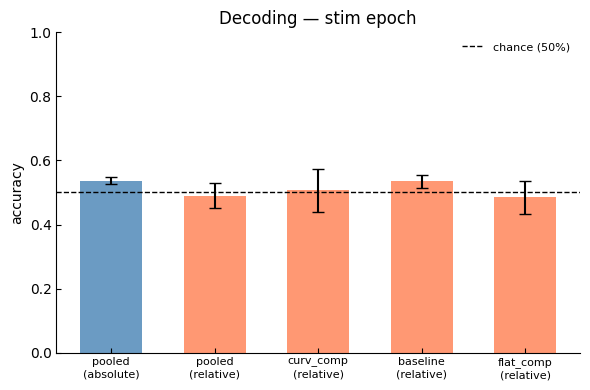

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = LogisticRegression(penalty=None, max_iter=1000)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def decode_across_patients(get_y, cond_filter=None):
    accs = []
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        X = pt_data[patient]['meanFRs']
        y = get_y(pt_psychopy_df)
        if cond_filter is not None:
            mask = pt_psychopy_df['condition'] == cond_filter
            X, y = X[mask], y[mask]
        accs.append(cross_val_score(clf, X, y, cv=cv, scoring='accuracy').mean())
    return np.array(accs)

# absolute_class: is true_stim above 0 regardless of boundary?
# relative_class: is true_stim above the boundary? (stim_boundary_aligned > 0 is consistent across subjects)
absolute_class = lambda df: (df['true_stim'] > 0).astype(int).values
relative_class = lambda df: (df['stim_boundary_aligned'] > 0).astype(int).values

# 5 bars: pooled-absolute, pooled-relative, then per-condition relative only
bar_specs = [
    ('pooled',     'absolute', absolute_class, None),
    ('pooled',     'relative', relative_class, None),
    ('curv_comp',  'relative', relative_class, 'curv_comp'),
    ('baseline',   'relative', relative_class, 'baseline'),
    ('flat_comp',  'relative', relative_class, 'flat_comp'),
]
labels    = [f'{scope}\n({target})' for scope, target, _, _ in bar_specs]
bar_data  = [decode_across_patients(get_y, cond) for _, _, get_y, cond in bar_specs]
colors    = ['steelblue', 'coral', 'coral', 'coral', 'coral']

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(bar_specs))
for i, (accs, color) in enumerate(zip(bar_data, colors)):
    ax.bar(x[i], accs.mean(), yerr=accs.std(), color=color, alpha=0.8, capsize=4, width=0.6)

ax.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=8)
ax.set_title(f'Decoding — {epoch} epoch')
plt.tight_layout()
plt.show()

In [26]:
# # do conditions separate in a shared geometry?
# # fit one PC space so differences show up as displacement, not just a rotation of coordinates
# view_elev, view_azim = 24, -65

# X_all     = np.vstack([cond_matrices[c] for c in conditions])
# pca_joint = PCA(n_components=3).fit(X_all)
# ev_j      = pca_joint.explained_variance_ratio_

# markers = {'baseline': 'o', 'curv_comp': '^', 'flat_comp': 's'}
# fig = plt.figure(figsize=(6, 5))
# ax  = fig.add_subplot(111, projection='3d')
# for cond in conditions:
#     coords = pca_joint.transform(cond_matrices[cond])
#     sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
#                     c=cond_pos_values[cond], cmap='coolwarm', vmin=-0.4, vmax=0.4,
#                     s=60, marker=markers[cond], linewidths=0, label=cond)

# plt.colorbar(sc, ax=ax, label='stim_pos')
# ax.legend(title='condition', loc='best', frameon=False)
# ax.set(title=f'Representations separate by context?',
#        xlabel=f'PC1 ({ev_j[0]*100:.1f}%)', ylabel=f'PC2 ({ev_j[1]*100:.1f}%)',
#        zlabel=f'PC3 ({ev_j[2]*100:.1f}%)')
# ax.view_init(elev=view_elev, azim=view_azim)
# plt.tight_layout()
# plt.show()